<a href="https://colab.research.google.com/github/RJL08/Modelos-de-Inteligencia-Artifical/blob/main/Jimenez_Ruben_Sistema_Inteligente_de_Detecci%C3%B3n_de_Plagas_Agr%C3%ADcolas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
# CELDA 1: Markdown de presentación
# Copiar y pegar esta celda como MARKDOWN (no código)

"""
#  Sistema Inteligente de Detección de Plagas Agrícolas
## Asistente Virtual para Agricultores con NLP + ASR + TTS

**Autor:** RJL08
**Fecha:** 2025-11-19
**Objetivo:** Desarrollar un sistema interactivo que procesa consultas agrícolas por voz o texto para diagnosticar plagas y recomendar tratamientos.

---

###  Tecnologías Implementadas
- **ASR (Automatic Speech Recognition)**: Whisper de OpenAI
- **NLP (Natural Language Processing)**: spaCy + EntityRuler
- **NER (Named Entity Recognition)**: Extracción de cultivos, síntomas, plagas
- **RE (Relation Extraction)**: Sistema basado en reglas
- **TTS (Text-to-Speech)**: Google Text-to-Speech (gTTS)
- **Simulación**: Sistema de diagnóstico y recomendaciones

---

###  Cultivos Gestionados
- 🍅 **Tomate**
- 🌶️ **Pimiento**
- 🍉 **Sandía**
- 🍓 **Fresa**
- 🍆 **Berenjena**

---

###  Problema Real
Según la FAO, las **plagas destruyen el 40% de los cultivos mundiales**, causando pérdidas de **$220 mil millones anuales**. Los agricultores pequeños no detectan plagas a tiempo, lo que resulta en uso excesivo de pesticidas.

Este sistema permite:
 Diagnóstico temprano de plagas
 Recomendaciones específicas de tratamiento
 Acceso a conocimiento especializado por voz
 Reducción del uso indiscriminado de pesticidas
"""

'\n#  Sistema Inteligente de Detección de Plagas Agrícolas\n## Asistente Virtual para Agricultores con NLP + ASR + TTS\n\n**Autor:** RJL08  \n**Fecha:** 2025-11-19  \n**Objetivo:** Desarrollar un sistema interactivo que procesa consultas agrícolas por voz o texto para diagnosticar plagas y recomendar tratamientos.\n\n---\n\n###  Tecnologías Implementadas\n- **ASR (Automatic Speech Recognition)**: Whisper de OpenAI\n- **NLP (Natural Language Processing)**: spaCy + EntityRuler\n- **NER (Named Entity Recognition)**: Extracción de cultivos, síntomas, plagas\n- **RE (Relation Extraction)**: Sistema basado en reglas\n- **TTS (Text-to-Speech)**: Google Text-to-Speech (gTTS)\n- **Simulación**: Sistema de diagnóstico y recomendaciones\n\n---\n\n###  Cultivos Gestionados\n- 🍅 **Tomate**\n- 🌶️ **Pimiento**\n- 🍉 **Sandía**\n- 🍓 **Fresa**\n- 🍆 **Berenjena**\n\n---\n\n###  Problema Real\nSegún la FAO, las **plagas destruyen el 40% de los cultivos mundiales**, causando pérdidas de **$220 mil millones

In [56]:
# CELDA 2: Instalación de dependencias

print("🔧 Instalando dependencias del sistema de gestión de plagas...")
print("="*70)

!pip install -q openai-whisper gtts spacy pandas numpy matplotlib
!python -m spacy download es_core_news_md
!apt-get install -y ffmpeg > /dev/null 2>&1

print("\n Todas las dependencias instaladas correctamente")
print("="*70)

🔧 Instalando dependencias del sistema de gestión de plagas...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 25.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

 Todas las dependencias instaladas correctamente


In [57]:
# CELDA 3: Importar todas las librerías necesarias

# CELDA 3: Importar librerías

# CELDA 3: Importar librerías y configurar logging

import whisper
import spacy
from spacy.matcher import Matcher
from spacy.pipeline import EntityRuler
from gtts import gTTS
from IPython.display import Audio, HTML, display, clear_output
import pandas as pd
import numpy as np
import json
import re
from collections import defaultdict
from datetime import datetime
import logging
import warnings
import base64
from io import StringIO

# Desactivar warnings
warnings.filterwarnings('ignore')

# Configurar logging (ESTO ES LO QUE FALTABA)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - [%(levelname)s] - %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

print(" Librerías importadas correctamente")
print(f" {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Usuario: RJL08")

 Librerías importadas correctamente
 2025-11-19 17:03:32
 Usuario: RJL08


In [58]:
# Celda 4 Carga del csv
plagas = pd.read_csv('sample_data/plagas.csv')
plagas.head()
print(" Dataset cargado correctamente")
print(f" Total de órdenes: {len(plagas)}")
print(f"\n Cultivos: {sorted(plagas['cultivo'].unique())}")
print(f" Plagas: {sorted(plagas['tipo_plaga'].unique())}")
print(f"  Acciones: {sorted(plagas['accion'].unique())}")
print(f" Ubicaciones únicas: {plagas['ubicacion'].nunique()}")
print(f" Severidades: {sorted(plagas['severidad'].unique())}")

# Estadísticas
print("\n Distribución por acción:")
display(plagas['accion'].value_counts())

 Dataset cargado correctamente
 Total de órdenes: 187

 Cultivos: ['berenjena', 'fresa', 'pimiento', 'sandía', 'tomate']
 Plagas: ['babosas', 'caracoles', 'hongos', 'minador', 'mosca blanca', 'mosquito verde', 'orugas', 'pulgones', 'trips', 'ácaros']
  Acciones: ['aislar', 'colocar_trampas', 'fumigar', 'marcar_riesgo', 'monitorizar', 'revisar']
 Ubicaciones únicas: 19
 Severidades: ['alta', 'baja', 'media']

 Distribución por acción:


,count
accion,
marcar_riesgo,37
colocar_trampas,34
revisar,32
aislar,31
monitorizar,28
fumigar,25


In [59]:
# CELDA 5: Interfaz de grabación de audio

recorded_audio = None

def create_audio_recorder():
    """Interfaz HTML/JS para grabar órdenes de trabajo por voz"""
    html_code = """
    <div style="
        text-align: center;
        padding: 25px;
        background: linear-gradient(135deg, #2E7D32 0%, #66BB6A 100%);
        border-radius: 15px;
        box-shadow: 0 8px 16px rgba(0,0,0,0.3);
    ">
        <h2 style="color: white; margin-bottom: 20px;">🎙️ Grabador de Órdenes Agrícolas</h2>
        <p style="color: white; margin-bottom: 15px;">Habla claramente tu orden de trabajo</p>

        <div style="margin: 20px 0;">
            <button id="startBtn" style="
                padding: 15px 30px;
                font-size: 18px;
                background: #D32F2F;
                color: white;
                border: none;
                border-radius: 50px;
                cursor: pointer;
                margin: 5px;
                box-shadow: 0 4px 8px rgba(0,0,0,0.2);
                transition: all 0.3s;
            " onmouseover="this.style.transform='scale(1.05)'"
               onmouseout="this.style.transform='scale(1)'">🔴 GRABAR</button>

            <button id="stopBtn" disabled style="
                padding: 15px 30px;
                font-size: 18px;
                background: #616161;
                color: white;
                border: none;
                border-radius: 50px;
                cursor: pointer;
                margin: 5px;
                opacity: 0.5;
            ">⏹️ DETENER</button>

            <button id="playBtn" disabled style="
                padding: 15px 30px;
                font-size: 18px;
                background: #1976D2;
                color: white;
                border: none;
                border-radius: 50px;
                cursor: pointer;
                margin: 5px;
                opacity: 0.5;
            ">▶️ REPRODUCIR</button>
        </div>

        <p id="status" style="
            margin-top: 20px;
            font-weight: bold;
            font-size: 16px;
            color: white;
            background: rgba(0,0,0,0.2);
            padding: 10px;
            border-radius: 10px;
        ">Estado: Listo para grabar orden 🟢</p>

        <audio id="audioPlayback" controls style="margin-top: 15px; display: none; width: 80%;"></audio>
    </div>

    <script>
    let mediaRecorder;
    let audioChunks = [];

    const startBtn = document.getElementById('startBtn');
    const stopBtn = document.getElementById('stopBtn');
    const playBtn = document.getElementById('playBtn');
    const status = document.getElementById('status');
    const audioPlayback = document.getElementById('audioPlayback');

    startBtn.onclick = async () => {
        try {
            const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
            mediaRecorder = new MediaRecorder(stream);
            audioChunks = [];

            mediaRecorder.ondataavailable = (event) => {
                audioChunks.push(event.data);
            };

            mediaRecorder.onstop = () => {
                const audioBlob = new Blob(audioChunks, { type: 'audio/wav' });
                const audioUrl = URL.createObjectURL(audioBlob);
                audioPlayback.src = audioUrl;
                audioPlayback.style.display = 'block';
                playBtn.disabled = false;
                playBtn.style.opacity = '1';

                const reader = new FileReader();
                reader.onloadend = () => {
                    const base64Audio = reader.result.split(',')[1];
                    google.colab.kernel.invokeFunction('notebook.save_audio', [base64Audio], {});
                };
                reader.readAsDataURL(audioBlob);

                status.textContent = 'Estado: Grabación completada ✅';
                status.style.background = 'rgba(76, 175, 80, 0.6)';
            };

            mediaRecorder.start();
            startBtn.disabled = true;
            startBtn.style.opacity = '0.5';
            stopBtn.disabled = false;
            stopBtn.style.opacity = '1';
            stopBtn.style.background = '#D32F2F';
            status.textContent = 'Estado: 🎙️ Grabando orden... (hable ahora)';
            status.style.background = 'rgba(211, 47, 47, 0.6)';
        } catch (err) {
            status.textContent = '❌ Error: ' + err.message;
            status.style.background = 'rgba(198, 40, 40, 0.6)';
        }
    };

    stopBtn.onclick = () => {
        mediaRecorder.stop();
        mediaRecorder.stream.getTracks().forEach(track => track.stop());
        startBtn.disabled = false;
        startBtn.style.opacity = '1';
        stopBtn.disabled = true;
        stopBtn.style.opacity = '0.5';
        stopBtn.style.background = '#616161';
        status.textContent = 'Estado: Procesando... ⏳';
        status.style.background = 'rgba(255, 152, 0, 0.6)';
    };

    playBtn.onclick = () => {
        audioPlayback.play();
    };
    </script>
    """
    return HTML(html_code)

def save_audio(audio_data):
    """Guardar audio desde JavaScript"""
    global recorded_audio
    recorded_audio = base64.b64decode(audio_data)
    with open('/content/recorded_audio.wav', 'wb') as f:
        f.write(recorded_audio)
    logger.info(" Audio guardado en /content/recorded_audio.wav")

# Registrar callback para Google Colab
from google.colab import output
output.register_callback('notebook.save_audio', save_audio)

print(" Sistema de grabación configurado")
print(" Función create_audio_recorder() lista para usar")

 Sistema de grabación configurado
 Función create_audio_recorder() lista para usar


In [60]:
# CELDA 6: Sistema de reconocimiento automático de voz (ASR)

class ASRProcessor:
    """Procesador de reconocimiento de voz con Whisper"""

    def __init__(self, model_name="base"):
        """
        Inicializa Whisper

        Args:
            model_name: 'tiny', 'base', 'small', 'medium', 'large'
        """
        logger.info(f" Cargando modelo Whisper '{model_name}'...")
        self.model = whisper.load_model(model_name)
        logger.info(" Modelo ASR listo")

    def transcribe(self, audio_path, language="es"):
        """
        Transcribe audio a texto

        Args:
            audio_path: ruta del archivo de audio
            language: idioma ('es' para español)

        Returns:
            str: texto transcrito
        """
        try:
            logger.info(f" Transcribiendo: {audio_path}")
            result = self.model.transcribe(audio_path, language=language)
            transcription = result["text"].strip()
            logger.info(f" Transcripción: '{transcription}'")
            return transcription
        except Exception as e:
            logger.error(f" Error en transcripción: {e}")
            return ""

# Inicializar ASR
print(" Inicializando sistema ASR con Whisper...")
asr_processor = ASRProcessor(model_name="base")
print(" Sistema ASR listo para transcribir órdenes de trabajo")

 Inicializando sistema ASR con Whisper...
 Sistema ASR listo para transcribir órdenes de trabajo


In [61]:
# CELDA 7: Sistema NER adaptado al dataset de plagas

class PlagasNER:
    """Sistema de reconocimiento de entidades para gestión de plagas"""

    def __init__(self, df_plagas):
        """
        Inicializa NER con vocabulario del dataset

        Args:
            df_plagas: DataFrame con el dataset de plagas
        """
        logger.info(" Inicializando sistema NER...")

        # Extraer entidades únicas del dataset
        self.CULTIVOS = sorted(df_plagas['cultivo'].unique().tolist())
        self.PLAGAS = sorted(df_plagas['tipo_plaga'].unique().tolist())
        self.ACCIONES = sorted(df_plagas['accion'].unique().tolist())
        self.UBICACIONES = sorted(df_plagas['ubicacion'].unique().tolist())
        self.SEVERIDADES = sorted(df_plagas['severidad'].unique().tolist())

        # Cantidades posibles
        self.CANTIDADES = [
            "muy pocas", "muy pocos", "unas pocas", "unos pocos",
            "algunas", "algunos", "varias", "varios",
            "muchas", "muchos", "cantidad elevada"
        ]

        # Cargar spaCy
        logger.info(" Cargando modelo spaCy...")
        self.nlp = spacy.load("es_core_news_md")

        # Añadir EntityRuler personalizado
        if "entity_ruler" not in self.nlp.pipe_names:
            ruler = self.nlp.add_pipe("entity_ruler", before="ner")
            patterns = self._create_patterns()
            ruler.add_patterns(patterns)

        # Matcher para patrones complejos
        self.matcher = Matcher(self.nlp.vocab)
        self._add_custom_patterns()

        logger.info(" Sistema NER inicializado con:")
        logger.info(f"   • {len(self.CULTIVOS)} cultivos")
        logger.info(f"   • {len(self.PLAGAS)} tipos de plagas")
        logger.info(f"   • {len(self.ACCIONES)} acciones")
        logger.info(f"   • {len(self.UBICACIONES)} ubicaciones")

    def _create_patterns(self):
        """Crea patrones para EntityRuler"""
        patterns = []

        # Cultivos
        for cultivo in self.CULTIVOS:
            patterns.append({"label": "CULTIVO", "pattern": cultivo})
            patterns.append({"label": "CULTIVO", "pattern": cultivo + "s"})  # plural
            patterns.append({"label": "CULTIVO", "pattern": "plantas de " + cultivo})

        # Plagas
        for plaga in self.PLAGAS:
            patterns.append({"label": "PLAGA", "pattern": plaga})
            # Variaciones comunes
            if plaga == "mosca blanca":
                patterns.append({"label": "PLAGA", "pattern": "moscas blancas"})
            elif plaga == "mosquito verde":
                patterns.append({"label": "PLAGA", "pattern": "mosquitos verdes"})

        # Acciones (verbos en infinitivo e imperativo)
        acciones_verbos = {
            "monitorizar": ["monitoriza", "monitorizar", "monitorear"],
            "fumigar": ["fumiga", "fumigar"],
            "revisar": ["revisa", "revisar", "inspeccionar"],
            "aislar": ["aísla", "aisla", "aislar"],
            "colocar_trampas": ["coloca trampas", "colocar trampas", "poner trampas"],
            "marcar_riesgo": ["marca", "marcar como zona de riesgo"]
        }

        for accion_base, variaciones in acciones_verbos.items():
            for var in variaciones:
                patterns.append({"label": "ACCION", "pattern": var})

        # Ubicaciones
        for ubicacion in self.UBICACIONES:
            patterns.append({"label": "UBICACION", "pattern": ubicacion})

        # Severidades
        for severidad in self.SEVERIDADES:
            patterns.append({"label": "SEVERIDAD", "pattern": severidad})

        # Cantidades
        for cantidad in self.CANTIDADES:
            patterns.append({"label": "CANTIDAD", "pattern": cantidad})

        return patterns

    def _add_custom_patterns(self):
        """Añade patrones complejos"""
        # Patrón: "en [ubicación]"
        location_pattern = [
            {"LOWER": "en"},
            {"ENT_TYPE": "UBICACION"}
        ]
        self.matcher.add("LOC_PATTERN", [location_pattern])

        # Patrón: "contra [plaga]"
        pest_pattern = [
            {"LOWER": "contra"},
            {"ENT_TYPE": "PLAGA"}
        ]
        self.matcher.add("PEST_PATTERN", [pest_pattern])

    def extract_entities(self, text):
        """
        Extrae entidades de una orden de trabajo

        Args:
            text: orden de trabajo en texto

        Returns:
            dict: entidades extraídas
        """
        doc = self.nlp(text.lower())

        entities = {
            "accion": None,
            "plaga": None,
            "cultivo": None,
            "cantidad": None,
            "ubicacion": None,
            "severidad": None
        }

        # Extraer entidades
        for ent in doc.ents:
            if ent.label_ == "ACCION" and not entities["accion"]:
                entities["accion"] = self._normalize_accion(ent.text)
            elif ent.label_ == "PLAGA" and not entities["plaga"]:
                entities["plaga"] = ent.text
            elif ent.label_ == "CULTIVO" and not entities["cultivo"]:
                entities["cultivo"] = self._extract_cultivo(ent.text)
            elif ent.label_ == "CANTIDAD" and not entities["cantidad"]:
                entities["cantidad"] = ent.text
            elif ent.label_ == "UBICACION" and not entities["ubicacion"]:
                entities["ubicacion"] = ent.text
            elif ent.label_ == "SEVERIDAD" and not entities["severidad"]:
                entities["severidad"] = ent.text

        # Inferir severidad si no está explícita
        if not entities["severidad"] and entities["cantidad"]:
            entities["severidad"] = self._inferir_severidad(entities["cantidad"])

        logger.info(f"🔍 Entidades: {entities}")
        return entities

    def _normalize_accion(self, accion_text):
        """Normaliza verbos a la acción base"""
        mapping = {
            "monitoriza": "monitorizar",
            "monitorear": "monitorizar",
            "fumiga": "fumigar",
            "revisa": "revisar",
            "inspeccionar": "revisar",
            "aísla": "aislar",
            "aisla": "aislar",
            "coloca trampas": "colocar_trampas",
            "poner trampas": "colocar_trampas",
            "marca": "marcar_riesgo"
        }
        return mapping.get(accion_text.lower(), accion_text)

    def _extract_cultivo(self, text):
        """Extrae el cultivo limpiando 'plantas de'"""
        text = text.replace("plantas de ", "")
        return text.strip()

    def _inferir_severidad(self, cantidad):
        """Infiere severidad según la cantidad"""
        if cantidad in ["muy pocas", "muy pocos", "unas pocas", "unos pocos"]:
            return "baja"
        elif cantidad in ["algunas", "algunos", "varias", "varios"]:
            return "media"
        elif cantidad in ["muchas", "muchos", "cantidad elevada"]:
            return "alta"
        return "media"

# Inicializar NER con el dataset
print(" Inicializando sistema NER con vocabulario del dataset...")
plagas_ner = PlagasNER(plagas)
print(" Sistema NER listo")


 Inicializando sistema NER con vocabulario del dataset...
 Sistema NER listo


In [62]:
# CELDA 8: Extractor de relaciones entre entidades

class RelationExtractor:
    """Extrae relaciones entre entidades de órdenes de trabajo"""

    def __init__(self, ner_system, df_plagas):
        """
        Inicializa extractor de relaciones

        Args:
            ner_system: sistema NER
            df_plagas: dataset de referencia
        """
        self.ner = ner_system
        self.df = df_plagas

    def extract_relations(self, entities):
        """
        Extrae relaciones estructuradas

        Args:
            entities: diccionario de entidades extraídas

        Returns:
            dict: relaciones estructuradas
        """
        relations = {
            "orden_id": self._generate_orden_id(),
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "accion": entities.get("accion"),
            "objetivo": {
                "plaga": entities.get("plaga"),
                "cultivo": entities.get("cultivo"),
                "cantidad": entities.get("cantidad")
            },
            "ubicacion": entities.get("ubicacion"),
            "severidad": entities.get("severidad"),
            "completeness": self._check_completeness(entities),
            "recomendacion": self._get_recomendacion(entities)
        }

        logger.info(f"🔗 Relaciones extraídas: {relations}")
        return relations

    def _generate_orden_id(self):
        """Genera ID único para la orden"""
        return f"ORD-{datetime.now().strftime('%Y%m%d%H%M%S')}"

    def _check_completeness(self, entities):
        """Verifica si la orden tiene información completa"""
        missing = []

        required_fields = ["accion", "plaga", "cultivo", "ubicacion"]

        for field in required_fields:
            if not entities.get(field):
                missing.append(field)

        return {
            "complete": len(missing) == 0,
            "missing": missing,
            "confidence": 1.0 - (len(missing) * 0.25)
        }

    def _get_recomendacion(self, entities):
        """Busca recomendaciones similares en el dataset"""
        accion = entities.get("accion")
        plaga = entities.get("plaga")
        cultivo = entities.get("cultivo")

        # Buscar en el dataset
        resultados = self.df[
            (self.df['accion'] == accion) &
            (self.df['tipo_plaga'] == plaga) &
            (self.df['cultivo'] == cultivo)
        ]

        if len(resultados) > 0:
            ejemplo = resultados.iloc[0]
            return {
                "existe": True,
                "notas": ejemplo['notas'],
                "severidad_tipica": ejemplo['severidad']
            }

        return {
            "existe": False,
            "notas": "No hay casos similares en el historial",
            "severidad_tipica": entities.get("severidad", "media")
        }

# Inicializar extractor
relation_extractor = RelationExtractor(plagas_ner, plagas)
print(" Extractor de relaciones listo")

 Extractor de relaciones listo


In [64]:
# CELDA 9: Simulador de gestión de parcelas y plagas

class PlagasSimulator:
    """Simulador de estado de parcelas y tratamientos"""

    def __init__(self, df_plagas):
        """
        Inicializa simulador

        Args:
            df_plagas: dataset de plagas
        """
        self.df = df_plagas
        self.ordenes_activas = []
        self.historial = []
        self.zonas_riesgo = set()
        self.ubicaciones_estado = defaultdict(lambda: {
            "cultivos": set(),
            "plagas_detectadas": defaultdict(int),
            "nivel_alerta": "normal"
        })

        logger.info(" Simulador inicializado")

    def procesar_orden(self, relations):
        """
        Procesa una orden de trabajo

        Args:
            relations: relaciones extraídas

        Returns:
            dict: resultado del procesamiento
        """
        # Verificar completitud
        if not relations["completeness"]["complete"]:
            return {
                "success": False,
                "message": "Orden incompleta",
                "missing": relations["completeness"]["missing"]
            }

        # Ejecutar según acción
        accion = relations["accion"]

        if accion == "monitorizar":
            return self._monitorizar(relations)
        elif accion == "fumigar":
            return self._fumigar(relations)
        elif accion == "revisar":
            return self._revisar(relations)
        elif accion == "aislar":
            return self._aislar(relations)
        elif accion == "colocar_trampas":
            return self._colocar_trampas(relations)
        elif accion == "marcar_riesgo":
            return self._marcar_riesgo(relations)
        else:
            return {
                "success": False,
                "message": f"Acción '{accion}' no reconocida"
            }

    def _monitorizar(self, relations):
        """Registra monitorización"""
        ubicacion = relations["ubicacion"]
        plaga = relations["objetivo"]["plaga"]
        cultivo = relations["objetivo"]["cultivo"]

        self.ubicaciones_estado[ubicacion]["cultivos"].add(cultivo)
        self.ubicaciones_estado[ubicacion]["plagas_detectadas"][plaga] += 1

        orden = {
            "id": relations["orden_id"],
            "accion": "monitorizar",
            "ubicacion": ubicacion,
            "plaga": plaga,
            "cultivo": cultivo,
            "timestamp": relations["timestamp"]
        }
        self.ordenes_activas.append(orden)
        self.historial.append(orden)

        return {
            "success": True,
            "message": f" Monitorización programada: {plaga} en {cultivo} ({ubicacion})",
            "icono": "📊",
            "orden_id": relations["orden_id"]
        }

    def _fumigar(self, relations):
        """Registra fumigación"""
        ubicacion = relations["ubicacion"]
        plaga = relations["objetivo"]["plaga"]
        cultivo = relations["objetivo"]["cultivo"]
        severidad = relations["severidad"]

        orden = {
            "id": relations["orden_id"],
            "accion": "fumigar",
            "ubicacion": ubicacion,
            "plaga": plaga,
            "cultivo": cultivo,
            "severidad": severidad,
            "timestamp": relations["timestamp"]
        }
        self.ordenes_activas.append(orden)
        self.historial.append(orden)

        # Reducir nivel de plaga
        if plaga in self.ubicaciones_estado[ubicacion]["plagas_detectadas"]:
            self.ubicaciones_estado[ubicacion]["plagas_detectadas"][plaga] = max(
                0,
                self.ubicaciones_estado[ubicacion]["plagas_detectadas"][plaga] - 2
            )

        return {
            "success": True,
            "message": f" Fumigación ejecutada contra {plaga} en {ubicacion} (severidad: {severidad})",
            "icono": "🚜",
            "orden_id": relations["orden_id"]
        }

    def _revisar(self, relations):
        """Registra revisión"""
        ubicacion = relations["ubicacion"]
        plaga = relations["objetivo"]["plaga"]
        cultivo = relations["objetivo"]["cultivo"]

        orden = {
            "id": relations["orden_id"],
            "accion": "revisar",
            "ubicacion": ubicacion,
            "plaga": plaga,
            "cultivo": cultivo,
            "timestamp": relations["timestamp"]
        }
        self.ordenes_activas.append(orden)
        self.historial.append(orden)

        return {
            "success": True,
            "message": f" Revisión programada: {cultivo} en {ubicacion} (buscar {plaga})",
            "icono": "🔍",
            "orden_id": relations["orden_id"]
        }

    def _aislar(self, relations):
        """Registra aislamiento"""
        ubicacion = relations["ubicacion"]
        plaga = relations["objetivo"]["plaga"]
        cultivo = relations["objetivo"]["cultivo"]

        orden = {
            "id": relations["orden_id"],
            "accion": "aislar",
            "ubicacion": ubicacion,
            "plaga": plaga,
            "cultivo": cultivo,
            "timestamp": relations["timestamp"]
        }
        self.ordenes_activas.append(orden)
        self.historial.append(orden)

        return {
            "success": True,
            "message": f" Aislamiento de plantas de {cultivo} afectadas por {plaga} en {ubicacion}",
            "icono": "🚧",
            "orden_id": relations["orden_id"]
        }

    def _colocar_trampas(self, relations):
        """Registra colocación de trampas"""
        ubicacion = relations["ubicacion"]
        plaga = relations["objetivo"]["plaga"]
        cultivo = relations["objetivo"]["cultivo"]

        orden = {
            "id": relations["orden_id"],
            "accion": "colocar_trampas",
            "ubicacion": ubicacion,
            "plaga": plaga,
            "cultivo": cultivo,
            "timestamp": relations["timestamp"]
        }
        self.ordenes_activas.append(orden)
        self.historial.append(orden)

        return {
            "success": True,
            "message": f" Trampas colocadas para {plaga} en {ubicacion} (cultivo: {cultivo})",
            "icono": "🪤",
            "orden_id": relations["orden_id"]
        }

    def _marcar_riesgo(self, relations):
        """Marca zona de riesgo"""
        ubicacion = relations["ubicacion"]
        plaga = relations["objetivo"]["plaga"]

        self.zonas_riesgo.add(ubicacion)
        self.ubicaciones_estado[ubicacion]["nivel_alerta"] = "alto"

        orden = {
            "id": relations["orden_id"],
            "accion": "marcar_riesgo",
            "ubicacion": ubicacion,
            "plaga": plaga,
            "timestamp": relations["timestamp"]
        }
        self.ordenes_activas.append(orden)
        self.historial.append(orden)

        return {
            "success": True,
            "message": f" {ubicacion} marcada como zona de riesgo por {plaga}",
            "icono": "⚠️",
            "orden_id": relations["orden_id"]
        }

    def get_estado_df(self):
        """Retorna estado de ubicaciones como DataFrame"""
        data = []
        for ubicacion, estado in self.ubicaciones_estado.items():
            plagas_str = ", ".join([f"{p}({n})" for p, n in estado["plagas_detectadas"].items()])
            cultivos_str = ", ".join(estado["cultivos"])

            data.append({
                "Ubicación": ubicacion,
                "Cultivos": cultivos_str if cultivos_str else "Sin registro",
                "Plagas Detectadas": plagas_str if plagas_str else "Ninguna",
                "Nivel Alerta": estado["nivel_alerta"],
                "Es Zona de Riesgo": "🔴 SÍ" if ubicacion in self.zonas_riesgo else "🟢 NO"
            })

        if not data:
            return pd.DataFrame(columns=["Ubicación", "Cultivos", "Plagas Detectadas", "Nivel Alerta", "Es Zona de Riesgo"])

        return pd.DataFrame(data)

    def get_historial_df(self):
        """Retorna historial de órdenes"""
        if not self.historial:
            return pd.DataFrame()

        return pd.DataFrame(self.historial)

# Inicializar simulador
simulator = PlagasSimulator(plagas)
print(" Simulador de gestión de plagas listo")

 Simulador de gestión de plagas listo


In [65]:
# CELDA 10: Sistema de síntesis de voz (TTS)

class TTSProcessor:
    """Procesador de texto a voz con gTTS"""

    def __init__(self, lang='es'):
        """
        Inicializa TTS

        Args:
            lang: código de idioma ('es' para español)
        """
        self.lang = lang
        self.counter = 0
        logger.info(" Sistema TTS inicializado")

    def speak(self, text, display_audio=True):
        """
        Convierte texto a voz y lo reproduce

        Args:
            text: texto a sintetizar
            display_audio: mostrar reproductor de audio

        Returns:
            Audio: objeto de audio de IPython
        """
        try:
            self.counter += 1
            filename = f'/content/response_{self.counter}.mp3'

            # Generar audio
            tts = gTTS(text=text, lang=self.lang, slow=False)
            tts.save(filename)

            logger.info(f"🔊 TTS generado: '{text[:60]}...'")

            # Crear objeto de audio
            audio = Audio(filename, autoplay=True)

            if display_audio:
                display(audio)

            return audio

        except Exception as e:
            logger.error(f" Error en TTS: {e}")
            return None

# Inicializar TTS
tts_processor = TTSProcessor()
print(" Sistema TTS listo para generar respuestas por voz")

 Sistema TTS listo para generar respuestas por voz


In [66]:
# CELDA 11: Sistema de diálogo integrado

class PlagasDialogSystem:
    """Sistema integrado de diálogo para gestión de plagas"""

    def __init__(self, asr, ner, re_extractor, simulator, tts):
        """
        Inicializa el sistema de diálogo

        Args:
            asr: procesador ASR
            ner: sistema NER
            re_extractor: extractor de relaciones
            simulator: simulador de plagas
            tts: procesador TTS
        """
        self.asr = asr
        self.ner = ner
        self.re_extractor = re_extractor
        self.simulator = simulator
        self.tts = tts
        logger.info(" Sistema de diálogo integrado")

    def process_voice_command(self, audio_path):
        """
        Procesa comando de voz completo

        Args:
            audio_path: ruta del archivo de audio
        """
        # 1. ASR: Transcribir audio
        text = self.asr.transcribe(audio_path)

        if not text:
            self._respond("No pude entender el audio. Por favor, intenta de nuevo.")
            return

        print(f"\n Transcripción: '{text}'\n")

        # Procesar como texto
        self.process_text_command(text)

    def process_text_command(self, text):
        """
        Procesa orden de trabajo desde texto

        Args:
            text: orden en texto
        """
        print(f"\n{'='*80}")
        print(f" NUEVA ORDEN DE TRABAJO")
        print(f"{'='*80}")
        print(f" Texto: {text}\n")

        # 2. NER: Extraer entidades
        entities = self.ner.extract_entities(text)

        # 3. RE: Extraer relaciones
        relations = self.re_extractor.extract_relations(entities)

        # 4. Verificar completitud
        if not relations["completeness"]["complete"]:
            self._handle_incomplete(relations, text)
            return

        # 5. Mostrar análisis
        self._display_analysis(relations)

        # 6. Ejecutar en simulador
        result = self.simulator.procesar_orden(relations)

        # 7. Generar respuesta
        if result["success"]:
            response = f"{result['icono']} {result['message']}"
            print(f"\n {result['message']}\n")

            # Agregar recomendación si existe
            if relations["recomendacion"]["existe"]:
                print(f"💡 Recomendación: {relations['recomendacion']['notas']}\n")
                response += f". {relations['recomendacion']['notas']}"

            self._respond(response)
        else:
            print(f"\n {result['message']}\n")
            self._respond(f"Error: {result['message']}")

        # 8. Mostrar estado actualizado
        self._display_status()

    def _handle_incomplete(self, relations, original_text):
        """
        Maneja órdenes incompletas

        Args:
            relations: relaciones extraídas
            original_text: texto original
        """
        missing = relations["completeness"]["missing"]
        confidence = relations["completeness"]["confidence"]

        print(f"\n  ORDEN INCOMPLETA (confianza: {confidence:.0%})")
        print(f" Falta información sobre: {', '.join(missing)}\n")

        questions = {
            "accion": "¿Qué acción debo realizar? (monitorizar, fumigar, revisar, aislar, colocar trampas, marcar riesgo)",
            "plaga": "¿Qué tipo de plaga es? (ácaros, trips, orugas, pulgones, mosca blanca, caracoles, hongos, babosas, minador, mosquito verde)",
            "cultivo": "¿En qué cultivo? (tomate, pimiento, sandía, fresa, berenjena)",
            "ubicacion": "¿En qué ubicación? (invernadero, sector, túnel, parcela, etc.)"
        }

        question = questions.get(missing[0], "Necesito más información para procesar la orden.")
        print(f" {question}\n")
        self._respond(question)

    def _display_analysis(self, relations):
        """
        Muestra análisis de la orden

        Args:
            relations: relaciones extraídas
        """
        print(f"{'─'*80}")
        print(f" ANÁLISIS DE LA ORDEN")
        print(f"{'─'*80}")
        print(f" ID Orden: {relations['orden_id']}")
        print(f"  Acción: {relations['accion']}")
        print(f" Plaga: {relations['objetivo']['plaga']}")
        print(f" Cultivo: {relations['objetivo']['cultivo']}")
        print(f" Cantidad: {relations['objetivo']['cantidad']}")
        print(f" Ubicación: {relations['ubicacion']}")
        print(f" Severidad: {relations['severidad']}")
        print(f" Confianza: {relations['completeness']['confidence']:.0%}")
        print(f"{'─'*80}\n")

    def _respond(self, text):
        """
        Genera respuesta por voz

        Args:
            text: texto a sintetizar
        """
        self.tts.speak(text)

    def _display_status(self):
        """Muestra estado actual del sistema"""
        print(f"\n{'='*80}")
        print(f" ESTADO ACTUAL DE PARCELAS")
        print(f"{'='*80}\n")

        df_estado = self.simulator.get_estado_df()
        if len(df_estado) > 0:
            display(df_estado)
        else:
            print(" No hay datos registrados aún\n")

        print(f"\n{'─'*80}")
        print(f" HISTORIAL DE ÓRDENES")
        print(f"{'─'*80}\n")

        df_historial = self.simulator.get_historial_df()
        if len(df_historial) > 0:
            print(f" Total de órdenes ejecutadas: {len(df_historial)}\n")
            display(df_historial.tail(5))  # Mostrar últimas 5
        else:
            print(" No hay historial aún\n")

        print(f"\n{'='*80}\n")

# Inicializar sistema de diálogo
dialog_system = PlagasDialogSystem(
    asr=asr_processor,
    ner=plagas_ner,
    re_extractor=relation_extractor,
    simulator=simulator,
    tts=tts_processor
)
print(" Sistema de diálogo integrado listo")

 Sistema de diálogo integrado listo


In [69]:
# CELDA 12: Interfaz principal del sistema

print("\n" + "="*80)
print(" SISTEMA INTELIGENTE DE GESTIÓN DE PLAGAS AGRÍCOLAS ")
print("="*80)
print("\n INSTRUCCIONES:")
print("   1.  Usa el grabador de audio para dar órdenes por voz")
print("   2.  O escribe comandos de texto directamente")
print("   3.  El sistema procesará y ejecutará tu orden")
print("\n EJEMPLOS DE ÓRDENES:")
print("   • 'Monitoriza ácaros en berenjena en invernadero 4'")
print("   • 'Fumiga contra orugas en tomate del invernadero 2'")
print("   • 'Revisa pimientos en parcela sur busca orugas'")
print("   • 'Coloca trampas para trips en sector C en fresa'")
print("   • 'Marca túnel 3 como zona de riesgo por mosca blanca'")
print("\n ¡Sistema listo para recibir órdenes!")
print("="*80 + "\n")

# Mostrar estado inicial
print(" Estado Inicial:")
df_inicial = simulator.get_estado_df()
if len(df_inicial) > 0:
    display(df_inicial)
else:
    print(" Sistema vacío - esperando primera orden\n")

print("\n" + "-"*80)
print(" GRABADOR DE AUDIO")
print("-"*80 + "\n")

# Mostrar grabador
display(create_audio_recorder())


 SISTEMA INTELIGENTE DE GESTIÓN DE PLAGAS AGRÍCOLAS 

 INSTRUCCIONES:
   1.  Usa el grabador de audio para dar órdenes por voz
   2.  O escribe comandos de texto directamente
   3.  El sistema procesará y ejecutará tu orden

 EJEMPLOS DE ÓRDENES:
   • 'Monitoriza ácaros en berenjena en invernadero 4'
   • 'Fumiga contra orugas en tomate del invernadero 2'
   • 'Revisa pimientos en parcela sur busca orugas'
   • 'Coloca trampas para trips en sector C en fresa'
   • 'Marca túnel 3 como zona de riesgo por mosca blanca'

 ¡Sistema listo para recibir órdenes!

 Estado Inicial:
 Sistema vacío - esperando primera orden


--------------------------------------------------------------------------------
 GRABADOR DE AUDIO
--------------------------------------------------------------------------------



In [71]:
# CELDA 12B MEJORADA: Generador de audio interactivo con campo de texto

from gtts import gTTS
from IPython.display import HTML, Audio, display, Javascript
import os

def mostrar_generador_audio_interactivo():
    """Interfaz HTML interactiva para generar audio desde texto"""
    html_code = """
    <div style="
        text-align: center;
        padding: 30px;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        border-radius: 15px;
        box-shadow: 0 10px 20px rgba(0,0,0,0.3);
        margin: 20px 0;
    ">
        <h2 style="color: white; margin-bottom: 20px; font-size: 28px;">
             Generador de Audio desde Texto
        </h2>

        <p style="color: white; margin-bottom: 20px; font-size: 16px;">
             <strong>Alternativa sin ruido:</strong> Escribe tu orden y genera audio perfecto
        </p>

        <!-- Área de texto para escribir la orden -->
        <div style="margin: 25px auto; max-width: 700px;">
            <textarea id="ordenTexto"
                placeholder="Ejemplo: Fumiga contra orugas en tomate del invernadero dos"
                style="
                    width: 100%;
                    height: 120px;
                    padding: 15px;
                    font-size: 16px;
                    border: 3px solid #fff;
                    border-radius: 10px;
                    box-sizing: border-box;
                    resize: vertical;
                    font-family: Arial, sans-serif;
                "
            ></textarea>
        </div>

        <!-- Botón para generar audio -->
        <button id="generarBtn" style="
            padding: 15px 40px;
            font-size: 18px;
            background: #4CAF50;
            color: white;
            border: none;
            border-radius: 50px;
            cursor: pointer;
            box-shadow: 0 4px 8px rgba(0,0,0,0.2);
            transition: all 0.3s;
            margin: 10px;
            font-weight: bold;
        " onmouseover="this.style.transform='scale(1.05)'; this.style.background='#45a049'"
           onmouseout="this.style.transform='scale(1)'; this.style.background='#4CAF50'">
             GENERAR AUDIO
        </button>

        <!-- Área de estado -->
        <div id="estadoGenerador" style="
            margin-top: 20px;
            padding: 15px;
            background: rgba(255,255,255,0.2);
            border-radius: 10px;
            color: white;
            font-size: 16px;
            min-height: 50px;
            display: flex;
            align-items: center;
            justify-content: center;
        ">
             Escribe tu orden arriba y haz clic en "GENERAR AUDIO"
        </div>

        <!-- Ejemplos rápidos -->
        <div style="
            margin-top: 25px;
            padding: 20px;
            background: rgba(255,255,255,0.1);
            border-radius: 10px;
            text-align: left;
            max-width: 700px;
            margin-left: auto;
            margin-right: auto;
        ">
            <h3 style="color: white; margin-bottom: 15px; font-size: 18px;">
                 Ejemplos rápidos (clic para usar):
            </h3>
            <div id="ejemplos" style="display: flex; flex-direction: column; gap: 10px;">
                <button class="ejemplo-btn" style="
                    padding: 12px;
                    background: rgba(255,255,255,0.2);
                    color: white;
                    border: 2px solid white;
                    border-radius: 8px;
                    cursor: pointer;
                    text-align: left;
                    transition: all 0.3s;
                    font-size: 14px;
                " onmouseover="this.style.background='rgba(255,255,255,0.3)'"
                   onmouseout="this.style.background='rgba(255,255,255,0.2)'">
                    Fumiga contra orugas en tomate del invernadero dos
                </button>
                <button class="ejemplo-btn" style="
                    padding: 12px;
                    background: rgba(255,255,255,0.2);
                    color: white;
                    border: 2px solid white;
                    border-radius: 8px;
                    cursor: pointer;
                    text-align: left;
                    transition: all 0.3s;
                    font-size: 14px;
                " onmouseover="this.style.background='rgba(255,255,255,0.3)'"
                   onmouseout="this.style.background='rgba(255,255,255,0.2)'">
                    Monitoriza ácaros en berenjena en invernadero cuatro
                </button>
                <button class="ejemplo-btn" style="
                    padding: 12px;
                    background: rgba(255,255,255,0.2);
                    color: white;
                    border: 2px solid white;
                    border-radius: 8px;
                    cursor: pointer;
                    text-align: left;
                    transition: all 0.3s;
                    font-size: 14px;
                " onmouseover="this.style.background='rgba(255,255,255,0.3)'"
                   onmouseout="this.style.background='rgba(255,255,255,0.2)'">
                    Revisa pimientos en parcela sur busca orugas
                </button>
                <button class="ejemplo-btn" style="
                    padding: 12px;
                    background: rgba(255,255,255,0.2);
                    color: white;
                    border: 2px solid white;
                    border-radius: 8px;
                    cursor: pointer;
                    text-align: left;
                    transition: all 0.3s;
                    font-size: 14px;
                " onmouseover="this.style.background='rgba(255,255,255,0.3)'"
                   onmouseout="this.style.background='rgba(255,255,255,0.2)'">
                    Coloca trampas para trips en sector C en fresa
                </button>
                <button class="ejemplo-btn" style="
                    padding: 12px;
                    background: rgba(255,255,255,0.2);
                    color: white;
                    border: 2px solid white;
                    border-radius: 8px;
                    cursor: pointer;
                    text-align: left;
                    transition: all 0.3s;
                    font-size: 14px;
                " onmouseover="this.style.background='rgba(255,255,255,0.3)'"
                   onmouseout="this.style.background='rgba(255,255,255,0.2)'">
                    Marca túnel tres como zona de riesgo por mosca blanca
                </button>
            </div>
        </div>
    </div>

    <script>
    // Función para generar audio
    document.getElementById('generarBtn').onclick = function() {
        const texto = document.getElementById('ordenTexto').value.trim();
        const estado = document.getElementById('estadoGenerador');

        if (!texto) {
            estado.innerHTML = ' Por favor, escribe una orden primero';
            estado.style.background = 'rgba(255, 152, 0, 0.3)';
            return;
        }

        estado.innerHTML = ' Generando audio... Por favor espera';
        estado.style.background = 'rgba(33, 150, 243, 0.3)';

        // Enviar texto a Python
        google.colab.kernel.invokeFunction('notebook.generar_audio', [texto], {})
            .then(function(result) {
                estado.innerHTML = ' Audio generado correctamente<br>▶ Ejecuta la CELDA 13 para procesar';
                estado.style.background = 'rgba(76, 175, 80, 0.3)';
            })
            .catch(function(error) {
                estado.innerHTML = ' Error al generar audio: ' + error;
                estado.style.background = 'rgba(244, 67, 54, 0.3)';
            });
    };

    // Botones de ejemplo
    const ejemplos = document.querySelectorAll('.ejemplo-btn');
    ejemplos.forEach(btn => {
        btn.onclick = function() {
            document.getElementById('ordenTexto').value = this.textContent.trim();
            // Scroll suave hacia el área de texto
            document.getElementById('ordenTexto').scrollIntoView({ behavior: 'smooth', block: 'center' });
            document.getElementById('ordenTexto').focus();
        };
    });

    // Enter para generar (Ctrl+Enter)
    document.getElementById('ordenTexto').addEventListener('keydown', function(e) {
        if (e.ctrlKey && e.key === 'Enter') {
            document.getElementById('generarBtn').click();
        }
    });
    </script>
    """
    return HTML(html_code)

# Función callback para generar audio desde JavaScript
def generar_audio_callback(texto):
    """
    Callback para generar audio desde JavaScript

    Args:
        texto: orden de trabajo en texto
    """
    try:
        logger.info(f" Generando audio desde interfaz web...")
        logger.info(f" Texto recibido: '{texto}'")

        # Ruta del archivo de audio
        audio_path = '/content/generated_audio.mp3'

        # Eliminar archivo anterior si existe
        if os.path.exists(audio_path):
            os.remove(audio_path)
            logger.info(" Archivo anterior eliminado")

        # Generar audio con gTTS
        tts = gTTS(text=texto, lang='es', slow=False)
        tts.save(audio_path)

        # VERIFICACIÓN CRÍTICA
        if not os.path.exists(audio_path):
            raise Exception("El archivo de audio no se creó")

        tamaño = os.path.getsize(audio_path)

        if tamaño == 0:
            raise Exception("El archivo de audio está vacío")

        logger.info(f" Audio generado: {audio_path} ({tamaño} bytes)")

        # Reproducir audio
        display(Audio(audio_path, autoplay=True))

        print("\n" + "="*80)
        print(" AUDIO GENERADO CORRECTAMENTE")
        print("="*80)
        print(f" Texto: '{texto}'")
        print(f" Archivo: {audio_path}")
        print(f" Tamaño: {tamaño} bytes ({tamaño/1024:.2f} KB)")
        print(f" Reproduciendo audio...")
        print(f"\n▶  SIGUIENTE PASO: Ejecuta la CELDA 13 para procesar la orden")
        print("="*80 + "\n")

        return {"success": True, "path": audio_path, "size": tamaño}

    except Exception as e:
        logger.error(f" Error generando audio: {e}")
        print(f"\n{'='*80}")
        print(f" ERROR AL GENERAR AUDIO")
        print(f"{'='*80}")
        print(f"Error: {e}\n")
        return {"success": False, "error": str(e)}

# Registrar callback
from google.colab import output
output.register_callback('notebook.generar_audio', generar_audio_callback)

# Mostrar interfaz
display(mostrar_generador_audio_interactivo())

print("\n" + "="*80)
print(" GENERADOR DE AUDIO INTERACTIVO LISTO")
print("="*80)
print("\n INSTRUCCIONES:")
print("   1. Escribe tu orden en el cuadro de texto")
print("   2. Haz clic en 'GENERAR AUDIO' (o usa los ejemplos rápidos)")
print("   3. Espera a que se genere y reproduzca el audio")
print("   4. Ejecuta la CELDA 13 para procesar la orden")
print("\n TIP: Puedes usar Ctrl+Enter en el campo de texto para generar")
print("="*80 + "\n")


 GENERADOR DE AUDIO INTERACTIVO LISTO

 INSTRUCCIONES:
   1. Escribe tu orden en el cuadro de texto
   2. Haz clic en 'GENERAR AUDIO' (o usa los ejemplos rápidos)
   3. Espera a que se genere y reproduzca el audio
   4. Ejecuta la CELDA 13 para procesar la orden

 TIP: Puedes usar Ctrl+Enter en el campo de texto para generar




 AUDIO GENERADO CORRECTAMENTE
 Texto: 'Monitoriza ácaros en berenjena en invernadero cuatro'
 Archivo: /content/generated_audio.mp3
 Tamaño: 33984 bytes (33.19 KB)
 Reproduciendo audio...

▶  SIGUIENTE PASO: Ejecuta la CELDA 13 para procesar la orden



In [72]:
# CELDA 13: Procesar comando de voz grabado

# CELDA 13: Procesar comando de voz (desde grabación O texto generado)

import os
import time

print("="*80)
print(" BUSCANDO Y PROCESANDO AUDIO")
print("="*80 + "\n")

# Definir archivos posibles
audio_grabado = "/content/recorded_audio.wav"
audio_generado = "/content/generated_audio.mp3"

# Buscar archivos con timestamp
archivos_disponibles = []

if os.path.exists(audio_generado):
    info = {
        "tipo": " Generado (TTS)",
        "path": audio_generado,
        "timestamp": os.path.getmtime(audio_generado),
        "tamaño": os.path.getsize(audio_generado),
        "prioridad": 1  # Mayor prioridad (más reciente)
    }
    archivos_disponibles.append(info)
    print(f" Encontrado: Audio generado desde texto")

if os.path.exists(audio_grabado):
    info = {
        "tipo": "🎤 Grabado (Micrófono)",
        "path": audio_grabado,
        "timestamp": os.path.getmtime(audio_grabado),
        "tamaño": os.path.getsize(audio_grabado),
        "prioridad": 2  # Menor prioridad
    }
    archivos_disponibles.append(info)
    print(f" Encontrado: Audio grabado con micrófono")

# Procesar archivo
if archivos_disponibles:
    # Ordenar por timestamp (más reciente) y prioridad
    archivos_disponibles.sort(key=lambda x: (x["prioridad"], -x["timestamp"]))

    audio_seleccionado = archivos_disponibles[0]

    print(f"\n{'─'*80}")
    print(f" PROCESANDO AUDIO SELECCIONADO")
    print(f"{'─'*80}")
    print(f" Tipo: {audio_seleccionado['tipo']}")
    print(f" Archivo: {audio_seleccionado['path']}")
    print(f" Tamaño: {audio_seleccionado['tamaño']/1024:.2f} KB")
    print(f" Última modificación: {time.ctime(audio_seleccionado['timestamp'])}")
    print(f"{'─'*80}\n")

    # Pequeña pausa para asegurar que el archivo está completo
    time.sleep(0.3)

    try:
        # PROCESAR CON EL SISTEMA DE DIÁLOGO
        dialog_system.process_voice_command(audio_seleccionado['path'])

        # Limpiar archivo generado después de procesarlo
        if audio_seleccionado['path'] == audio_generado:
            try:
                os.remove(audio_generado)
                print(f"\n  Audio generado procesado y eliminado")
                print(f" Para generar uno nuevo, usa la CELDA 12B\n")
            except:
                pass

    except Exception as e:
        print(f"\n{'='*80}")
        print(f" ERROR AL PROCESAR AUDIO")
        print(f"{'='*80}")
        print(f"Error: {e}\n")
        logger.error(f"Error procesando audio: {e}")

else:
    # NO HAY ARCHIVOS DE AUDIO
    print(f"\n{'='*80}")
    print("  NO SE ENCONTRÓ NINGÚN AUDIO")
    print(f"{'='*80}\n")

    print(" OPCIONES DISPONIBLES:\n")

    print("1️  OPCIÓN A - Generar audio desde texto (RECOMENDADO ):")
    print("   • Sin ruido de fondo")
    print("   • Pronunciación perfecta")
    print("   • 100% preciso")
    print("\n    PASOS:")
    print("      1. Ve a la CELDA 12B (arriba)")
    print("      2. Escribe tu orden en el cuadro de texto")
    print("      3. Haz clic en ' GENERAR AUDIO'")
    print("      4. Espera el mensaje ' Audio generado correctamente'")
    print("      5. Vuelve a ejecutar esta celda (CELDA 13)")
    print()

    print("2️  OPCIÓN B - Grabar con micrófono:")
    print("    PASOS:")
    print("      1. Ve a la CELDA 12 (grabador)")
    print("      2. Haz clic en  GRABAR")
    print("      3. Habla tu orden LENTO y CLARO")
    print("      4. Haz clic en ⏹ DETENER")
    print("      5. Vuelve a ejecutar esta celda (CELDA 13)")
    print()

    print("3️  OPCIÓN C - Texto directo (MÁS RÁPIDO ⚡):")
    print("   • No necesita audio")
    print("   • Procesamiento inmediato")
    print("    Usa la CELDA 14")
    print()

    print(f"{'='*80}\n")

 BUSCANDO Y PROCESANDO AUDIO

 Encontrado: Audio generado desde texto
 Encontrado: Audio grabado con micrófono

────────────────────────────────────────────────────────────────────────────────
 PROCESANDO AUDIO SELECCIONADO
────────────────────────────────────────────────────────────────────────────────
 Tipo:  Generado (TTS)
 Archivo: /content/generated_audio.mp3
 Tamaño: 33.19 KB
 Última modificación: Wed Nov 19 17:08:22 2025
────────────────────────────────────────────────────────────────────────────────


 Transcripción: 'Monitoriza a Carlos en Verenjena en Invernadero 4.'


 NUEVA ORDEN DE TRABAJO
 Texto: Monitoriza a Carlos en Verenjena en Invernadero 4.


  ORDEN INCOMPLETA (confianza: 50%)
 Falta información sobre: plaga, cultivo

 ¿Qué tipo de plaga es? (ácaros, trips, orugas, pulgones, mosca blanca, caracoles, hongos, babosas, minador, mosquito verde)




  Audio generado procesado y eliminado
 Para generar uno nuevo, usa la CELDA 12B



In [74]:
# CELDA 13B: Diagnóstico de archivos de audio (OPCIONAL)

import os
from datetime import datetime

print("="*80)
print(" DIAGNÓSTICO DE ARCHIVOS DE AUDIO")
print("="*80 + "\n")

archivos = {
    " Audio Generado (TTS)": "/content/generated_audio.mp3",
    " Audio Grabado (Micrófono)": "/content/recorded_audio.wav"
}

archivos_encontrados = 0

for nombre, ruta in archivos.items():
    print(f"{nombre}:")

    if os.path.exists(ruta):
        tamaño = os.path.getsize(ruta)
        timestamp = os.path.getmtime(ruta)
        fecha = datetime.fromtimestamp(timestamp).strftime("%Y-%m-%d %H:%M:%S")

        print(f"    EXISTE")
        print(f"    Ruta: {ruta}")
        print(f"    Tamaño: {tamaño:,} bytes ({tamaño/1024:.2f} KB)")
        print(f"    Modificado: {fecha}")

        if tamaño == 0:
            print(f"     ADVERTENCIA: Archivo vacío")

        archivos_encontrados += 1
    else:
        print(f"    NO EXISTE")
        print(f"    Ruta esperada: {ruta}")

    print()

print("─"*80)
if archivos_encontrados > 0:
    print(f" {archivos_encontrados} archivo(s) disponible(s)")
    print("\n Ejecuta CELDA 13 para procesar")
else:
    print(" No hay archivos disponibles")
    print("\n Genera audio con CELDA 12 o CELDA 12B")

print("="*80 + "\n")

 DIAGNÓSTICO DE ARCHIVOS DE AUDIO

 Audio Generado (TTS):
    NO EXISTE
    Ruta esperada: /content/generated_audio.mp3

 Audio Grabado (Micrófono):
    EXISTE
    Ruta: /content/recorded_audio.wav
    Tamaño: 66,933 bytes (65.36 KB)
    Modificado: 2025-11-19 15:55:52

────────────────────────────────────────────────────────────────────────────────
 1 archivo(s) disponible(s)

 Ejecuta CELDA 13 para procesar



In [75]:
# CELDA 14: Procesar comando de texto

# Escribe tu orden aquí
comando = "Monitoriza ácaros en berenjena en invernadero 4"

print("⌨  Procesando comando de texto...\n")
dialog_system.process_text_command(comando)

⌨  Procesando comando de texto...


 NUEVA ORDEN DE TRABAJO
 Texto: Monitoriza ácaros en berenjena en invernadero 4

────────────────────────────────────────────────────────────────────────────────
 ANÁLISIS DE LA ORDEN
────────────────────────────────────────────────────────────────────────────────
 ID Orden: ORD-20251119170954
  Acción: monitorizar
 Plaga: ácaros
 Cultivo: berenjena
 Cantidad: None
 Ubicación: invernadero 4
 Severidad: None
 Confianza: 100%
────────────────────────────────────────────────────────────────────────────────


  Monitorización programada: ácaros en berenjena (invernadero 4)

💡 Recomendación: Seguimiento continuo




 ESTADO ACTUAL DE PARCELAS



,Ubicación,Cultivos,Plagas Detectadas,Nivel Alerta,Es Zona de Riesgo
0,invernadero 4,berenjena,ácaros(1),normal,🟢 NO



────────────────────────────────────────────────────────────────────────────────
 HISTORIAL DE ÓRDENES
────────────────────────────────────────────────────────────────────────────────

 Total de órdenes ejecutadas: 1



,id,accion,ubicacion,plaga,cultivo,timestamp
0,ORD-20251119170954,monitorizar,invernadero 4,ácaros,berenjena,2025-11-19 17:09:54


In [76]:
# CELDA 15 MEJORADA: Pruebas automáticas con sincronización de audio

import time
from gtts import gTTS
from IPython.display import Audio, clear_output
import threading

print("\n" + "="*80)
print(" EJECUTANDO PRUEBAS AUTOMÁTICAS DEL SISTEMA")
print("="*80 + "\n")

# Configuración de pruebas
NUM_PRUEBAS = 10  # Número de casos a probar
PAUSA_ENTRE_PRUEBAS = 3  # Segundos de pausa entre cada prueba
REPRODUCIR_AUDIO = True  # Cambiar a False para desactivar audio y acelerar

print(f"  CONFIGURACIÓN:")
print(f"   • Número de pruebas: {NUM_PRUEBAS}")
print(f"   • Pausa entre pruebas: {PAUSA_ENTRE_PRUEBAS} segundos")
print(f"   • Reproducir audio: {'Sí' if REPRODUCIR_AUDIO else 'No'}")
print(f"\n{'='*80}\n")

# Seleccionar casos aleatorios del dataset
casos_prueba = plagas.sample(n=min(NUM_PRUEBAS, len(plagas)), random_state=42)

# Contador de resultados
resultados = {
    "exitosas": 0,
    "fallidas": 0,
    "incompletas": 0
}

# Función para calcular duración aproximada del audio
def calcular_duracion_audio(texto):
    """
    Calcula duración aproximada del audio en segundos

    Args:
        texto: texto a sintetizar

    Returns:
        float: duración estimada en segundos
    """
    # Promedio: ~150 palabras por minuto en español
    palabras = len(texto.split())
    duracion = (palabras / 150) * 60
    return max(duracion + 1, 2)  # Mínimo 2 segundos

# Ejecutar pruebas
for idx, (_, caso) in enumerate(casos_prueba.iterrows(), 1):
    print(f"\n{'─'*80}")
    print(f" TEST #{idx}/{NUM_PRUEBAS} - {caso['accion'].upper()}")
    print(f"{'─'*80}")
    print(f" Orden: '{caso['texto_orden']}'")
    print(f" Plaga: {caso['tipo_plaga']}")
    print(f" Cultivo: {caso['cultivo']}")
    print(f" Ubicación: {caso['ubicacion']}")
    print(f" Severidad: {caso['severidad']}")
    print(f"{'─'*80}\n")

    try:
        # Deshabilitar temporalmente TTS durante pruebas masivas
        if REPRODUCIR_AUDIO:
            print("🔊 Generando y reproduciendo audio de respuesta...")

            # Procesar la orden (con TTS normal)
            dialog_system.process_text_command(caso['texto_orden'])

            # Calcular tiempo de espera basado en el texto
            duracion_estimada = calcular_duracion_audio(caso['texto_orden'])
            print(f"\n⏳ Esperando {duracion_estimada:.1f}s a que termine el audio...")
            time.sleep(duracion_estimada)

        else:
            # Procesar sin audio (más rápido)
            # Guardar el procesador TTS original
            tts_original = dialog_system.tts

            # Crear un TTS silencioso temporal
            class SilentTTS:
                def speak(self, text, display_audio=True):
                    print(f" [Audio silenciado]: '{text[:50]}...'")
                    return None

            dialog_system.tts = SilentTTS()

            # Procesar
            dialog_system.process_text_command(caso['texto_orden'])

            # Restaurar TTS original
            dialog_system.tts = tts_original

        resultados["exitosas"] += 1
        print(f"\n Test #{idx} completado exitosamente")

    except Exception as e:
        resultados["fallidas"] += 1
        print(f"\n Test #{idx} falló: {e}")
        logger.error(f"Error en test #{idx}: {e}")

    # Pausa entre pruebas
    if idx < NUM_PRUEBAS:
        print(f"\n⏸  Pausa de {PAUSA_ENTRE_PRUEBAS}s antes del siguiente test...")

        # Countdown visual
        for seg in range(PAUSA_ENTRE_PRUEBAS, 0, -1):
            print(f"   ⏱  {seg}...", end="\r")
            time.sleep(1)

        print(" " * 20, end="\r")  # Limpiar línea
        print()

# Resumen final
print("\n" + "="*80)
print(" PRUEBAS COMPLETADAS")
print("="*80)

print(f"\n RESULTADOS:")
print(f"    Exitosas: {resultados['exitosas']}/{NUM_PRUEBAS}")
print(f"    Fallidas: {resultados['fallidas']}/{NUM_PRUEBAS}")
print(f"    Tasa de éxito: {(resultados['exitosas']/NUM_PRUEBAS)*100:.1f}%")

print(f"\n ESTADO FINAL DEL SISTEMA:")
print(f"   • Órdenes procesadas: {len(simulator.historial)}")
print(f"   • Zonas de riesgo: {len(simulator.zonas_riesgo)}")
print(f"   • Ubicaciones monitoreadas: {len(simulator.ubicaciones_estado)}")

# Mostrar estado final
print("\n ESTADO DE PARCELAS:")
df_estado = simulator.get_estado_df()
if len(df_estado) > 0:
    display(df_estado)
else:
    print(" Sin datos registrados")

# Mostrar últimas 10 órdenes
print("\n ÚLTIMAS 10 ÓRDENES EJECUTADAS:")
df_historial = simulator.get_historial_df()
if len(df_historial) > 0:
    display(df_historial.tail(10))
else:
    print(" Sin historial")

print("\n" + "="*80)
print(" ¡PRUEBAS AUTOMÁTICAS FINALIZADAS!")
print("="*80 + "\n")


 EJECUTANDO PRUEBAS AUTOMÁTICAS DEL SISTEMA

  CONFIGURACIÓN:
   • Número de pruebas: 10
   • Pausa entre pruebas: 3 segundos
   • Reproducir audio: Sí



────────────────────────────────────────────────────────────────────────────────
 TEST #1/10 - MONITORIZAR
────────────────────────────────────────────────────────────────────────────────
 Orden: 'Monitoriza el nivel de orugas en sandía en borde del camino durante los próximos días.'
 Plaga: orugas
 Cultivo: sandía
 Ubicación: borde del camino
 Severidad: baja
────────────────────────────────────────────────────────────────────────────────

🔊 Generando y reproduciendo audio de respuesta...

 NUEVA ORDEN DE TRABAJO
 Texto: Monitoriza el nivel de orugas en sandía en borde del camino durante los próximos días.

────────────────────────────────────────────────────────────────────────────────
 ANÁLISIS DE LA ORDEN
────────────────────────────────────────────────────────────────────────────────
 ID Orden: ORD-20251119171031
  Acción: moni


 ESTADO ACTUAL DE PARCELAS



,Ubicación,Cultivos,Plagas Detectadas,Nivel Alerta,Es Zona de Riesgo
0,invernadero 4,berenjena,ácaros(1),normal,🟢 NO
1,borde del camino,sandía,orugas(1),normal,🟢 NO



────────────────────────────────────────────────────────────────────────────────
 HISTORIAL DE ÓRDENES
────────────────────────────────────────────────────────────────────────────────

 Total de órdenes ejecutadas: 2



,id,accion,ubicacion,plaga,cultivo,timestamp
0,ORD-20251119170954,monitorizar,invernadero 4,ácaros,berenjena,2025-11-19 17:09:54
1,ORD-20251119171031,monitorizar,borde del camino,orugas,sandía,2025-11-19 17:10:31


...

,Ubicación,Cultivos,Plagas Detectadas,Nivel Alerta,Es Zona de Riesgo
0,invernadero 4,berenjena,ácaros(1),normal,🟢 NO
1,borde del camino,sandía,orugas(1),normal,🟢 NO
2,túnel 1,Sin registro,Ninguna,normal,🟢 NO



────────────────────────────────────────────────────────────────────────────────
 HISTORIAL DE ÓRDENES
────────────────────────────────────────────────────────────────────────────────

 Total de órdenes ejecutadas: 3



,id,accion,ubicacion,plaga,cultivo,timestamp,severidad
0,ORD-20251119170954,monitorizar,invernadero 4,ácaros,berenjena,2025-11-19 17:09:54,NaN
1,ORD-20251119171031,monitorizar,borde del camino,orugas,sandía,2025-11-19 17:10:31,NaN
2,ORD-20251119171041,fumigar,túnel 1,mosca blanca,pimiento,2025-11-19 17:10:41,baja





⏳ Esperando 7.4s a que termine el audio...

 Test #2 completado exitosamente

⏸  Pausa de 3s antes del siguiente test...


KeyboardInterrupt: 

In [77]:
# CELDA 15B: Configuración de pruebas automáticas

print("="*80)
print("  CONFIGURACIÓN DE PRUEBAS AUTOMÁTICAS")
print("="*80 + "\n")

# Variables configurables
config_pruebas = {
    "num_pruebas": 5,           # Número de casos a probar (1-100)
    "pausa_entre_pruebas": 3,   # Segundos entre cada prueba (0-10)
    "reproducir_audio": False,  # True = con audio, False = sin audio (más rápido)
    "mostrar_detalle": True,    # Mostrar análisis detallado de cada orden
    "random_seed": 42           # Semilla para reproducibilidad
}

print(" Configuración actual:")
for key, value in config_pruebas.items():
    print(f"   • {key}: {value}")

print("\n OPCIONES:")
print("   • Para pruebas RÁPIDAS: reproducir_audio = False")
print("   • Para pruebas COMPLETAS: reproducir_audio = True")
print("   • Para DEMOSTRACIÓN: num_pruebas = 3-5")
print("   • Para TESTING: num_pruebas = 20-50")

print("\n Configuración lista. Ejecuta CELDA 15 para iniciar pruebas")
print("="*80 + "\n")

  CONFIGURACIÓN DE PRUEBAS AUTOMÁTICAS

 Configuración actual:
   • num_pruebas: 5
   • pausa_entre_pruebas: 3
   • reproducir_audio: False
   • mostrar_detalle: True
   • random_seed: 42

 OPCIONES:
   • Para pruebas RÁPIDAS: reproducir_audio = False
   • Para pruebas COMPLETAS: reproducir_audio = True
   • Para DEMOSTRACIÓN: num_pruebas = 3-5
   • Para TESTING: num_pruebas = 20-50

 Configuración lista. Ejecuta CELDA 15 para iniciar pruebas




 ESTADÍSTICAS Y VISUALIZACIONES



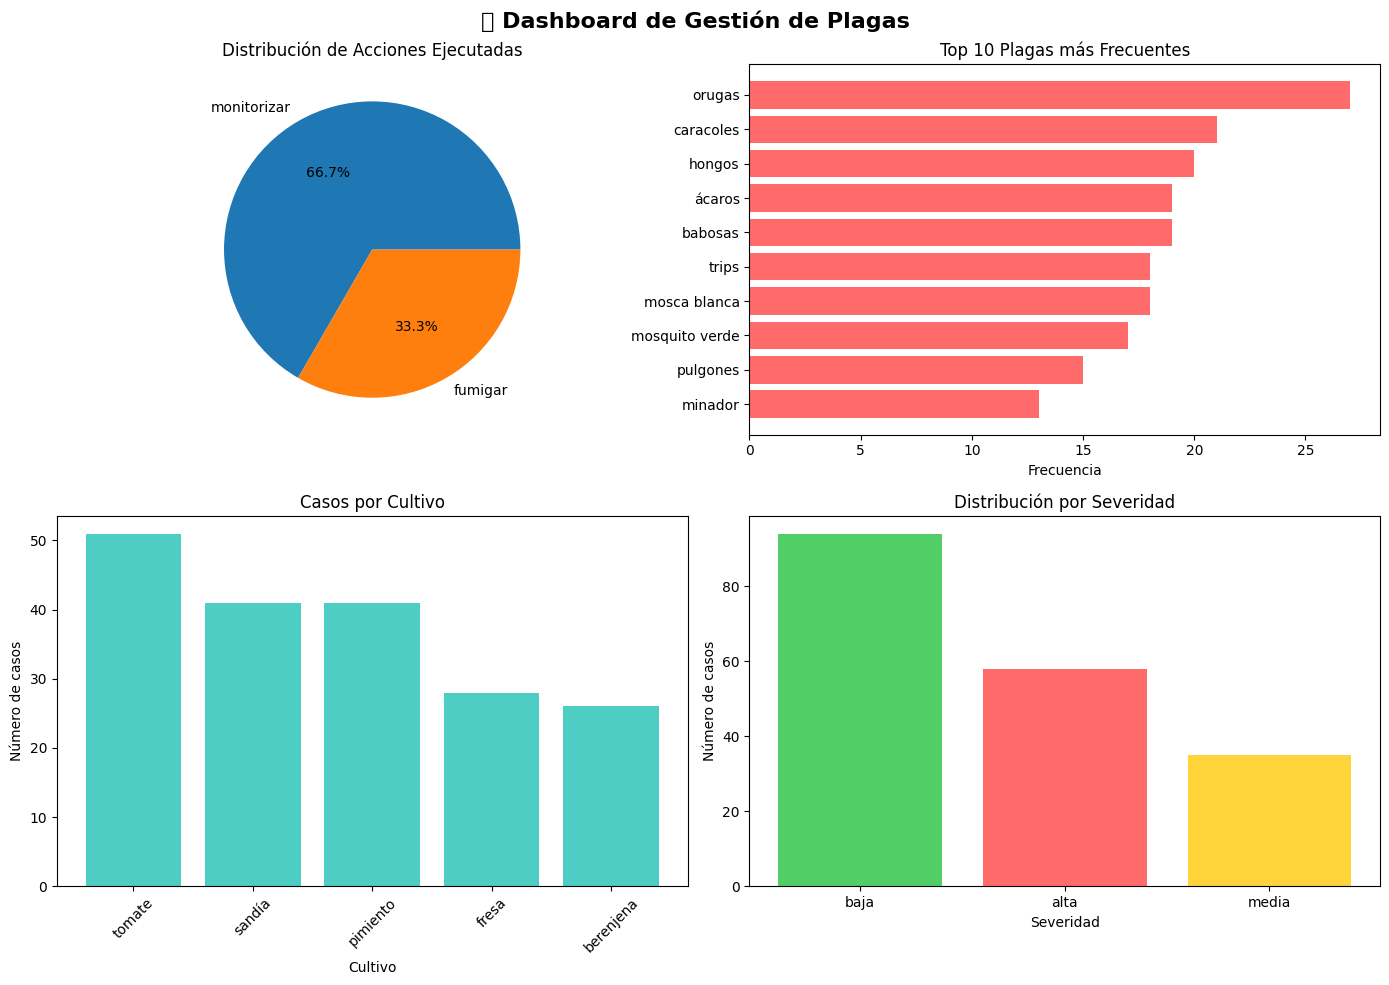


 Visualizaciones generadas


In [78]:
# CELDA 16: Visualización de estadísticas

import matplotlib.pyplot as plt

print("\n" + "="*80)
print(" ESTADÍSTICAS Y VISUALIZACIONES")
print("="*80 + "\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🌾 Dashboard de Gestión de Plagas', fontsize=16, fontweight='bold')

# 1. Distribución de acciones ejecutadas
if len(simulator.historial) > 0:
    df_hist = simulator.get_historial_df()
    acciones_counts = df_hist['accion'].value_counts()

    axes[0, 0].pie(acciones_counts.values, labels=acciones_counts.index, autopct='%1.1f%%')
    axes[0, 0].set_title('Distribución de Acciones Ejecutadas')
else:
    axes[0, 0].text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    axes[0, 0].set_title('Distribución de Acciones')

# 2. Plagas más frecuentes
plagas_freq = plagas['tipo_plaga'].value_counts().head(10)
axes[0, 1].barh(plagas_freq.index, plagas_freq.values, color='#FF6B6B')
axes[0, 1].set_xlabel('Frecuencia')
axes[0, 1].set_title('Top 10 Plagas más Frecuentes')
axes[0, 1].invert_yaxis()

# 3. Distribución por cultivo
cultivos_counts = plagas['cultivo'].value_counts()
axes[1, 0].bar(cultivos_counts.index, cultivos_counts.values, color='#4ECDC4')
axes[1, 0].set_xlabel('Cultivo')
axes[1, 0].set_ylabel('Número de casos')
axes[1, 0].set_title('Casos por Cultivo')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Distribución de severidad
severidad_counts = plagas['severidad'].value_counts()
colores = {'baja': '#51CF66', 'media': '#FFD43B', 'alta': '#FF6B6B'}
colors = [colores.get(sev, '#999') for sev in severidad_counts.index]

axes[1, 1].bar(severidad_counts.index, severidad_counts.values, color=colors)
axes[1, 1].set_xlabel('Severidad')
axes[1, 1].set_ylabel('Número de casos')
axes[1, 1].set_title('Distribución por Severidad')

plt.tight_layout()
plt.show()
print("\n Visualizaciones generadas")

In [79]:
# CELDA 17: Exportar resultados del sistema

print("\n" + "="*80)
print(" EXPORTANDO RESULTADOS")
print("="*80 + "\n")

# 1. Exportar historial de órdenes
if len(simulator.historial) > 0:
    df_historial = simulator.get_historial_df()
    df_historial.to_csv('/content/historial_ordenes.csv', index=False)
    print(" Historial exportado: historial_ordenes.csv")

# 2. Exportar estado de parcelas
df_estado = simulator.get_estado_df()
if len(df_estado) > 0:
    df_estado.to_csv('/content/estado_parcelas.csv', index=False)
    print(" Estado de parcelas exportado: estado_parcelas.csv")

# 3. Exportar zonas de riesgo
if simulator.zonas_riesgo:
    with open('/content/zonas_riesgo.json', 'w', encoding='utf-8') as f:
        json.dump({
            "zonas": list(simulator.zonas_riesgo),
            "total": len(simulator.zonas_riesgo),
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }, f, indent=2, ensure_ascii=False)
    print(" Zonas de riesgo exportadas: zonas_riesgo.json")

# 4. Generar informe completo
informe = {
    "fecha_generacion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "usuario": "RJL08",
    "estadisticas": {
        "total_ordenes": len(simulator.historial),
        "zonas_riesgo": len(simulator.zonas_riesgo),
        "ubicaciones_monitoreadas": len(simulator.ubicaciones_estado)
    },
    "zonas_riesgo_activas": list(simulator.zonas_riesgo)
}

with open('/content/informe_sistema.json', 'w', encoding='utf-8') as f:
    json.dump(informe, f, indent=2, ensure_ascii=False)

print(" Informe del sistema exportado: informe_sistema.json")

print("\n Archivos generados:")
print("   • historial_ordenes.csv")
print("   • estado_parcelas.csv")
print("   • zonas_riesgo.json")
print("   • informe_sistema.json")

# Descargar archivos
from google.colab import files

try:
    files.download('/content/historial_ordenes.csv')
    files.download('/content/estado_parcelas.csv')
    files.download('/content/zonas_riesgo.json')
    files.download('/content/informe_sistema.json')
    print("\n Archivos descargados correctamente")
except Exception as e:
    print(f"\n  Para descargar manualmente, busca los archivos en /content/")


 EXPORTANDO RESULTADOS

 Historial exportado: historial_ordenes.csv
 Estado de parcelas exportado: estado_parcelas.csv
 Informe del sistema exportado: informe_sistema.json

 Archivos generados:
   • historial_ordenes.csv
   • estado_parcelas.csv
   • zonas_riesgo.json
   • informe_sistema.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Archivos descargados correctamente
